<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `AnalysisExamples.mlx`
- Fidelity status: `exact`
- Remaining justified differences: The notebook now follows the MATLAB standard-GLM workflow with the canonical `glm_data.mat` dataset and real KS/model-visualization figures; coefficient values and styling still vary modestly because the Python GLM backend and plotting defaults differ from MATLAB.


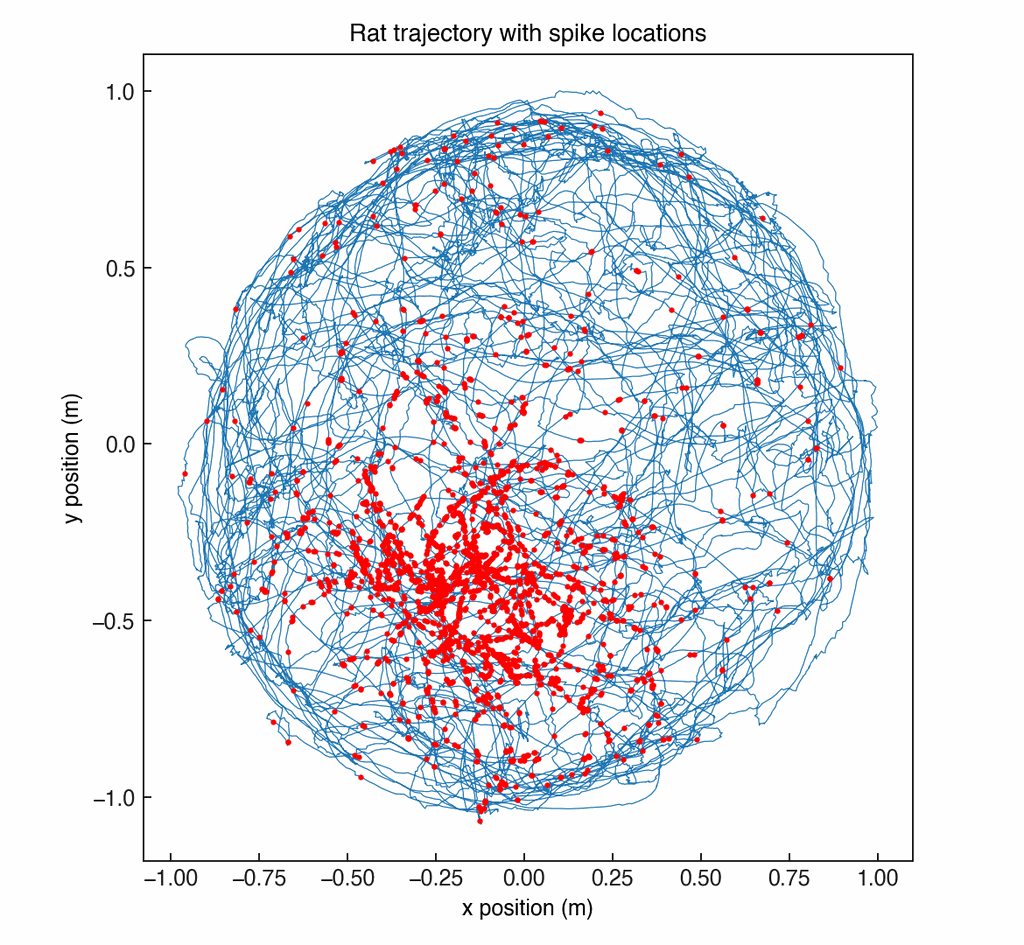

In [ ]:
# nSTAT-python notebook example: AnalysisExamples
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import Analysis, Covariate, nspikeTrain
from nstat.glm import fit_poisson_glm
from nstat.notebook_data import load_glm_data_for_notebook
from nstat.notebook_figures import FigureTracker, matlab_trajectory_axes

GLM_DATA = load_glm_data_for_notebook()
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="AnalysisExamples", output_root=OUTPUT_ROOT, expected_count=4)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _poisson_standard_errors(design_matrix, result):
    x = np.asarray(design_matrix, dtype=float)
    if x.ndim == 1:
        x = x[:, None]
    x_aug = np.column_stack([np.ones(x.shape[0]), x])
    beta = np.concatenate([[result.intercept], np.asarray(result.coefficients, dtype=float)])
    lam = np.exp(np.clip(x_aug @ beta, -20.0, 20.0))
    cov = np.linalg.pinv(x_aug.T @ (lam[:, None] * x_aug))
    return np.sqrt(np.clip(np.diag(cov), 0.0, None))


T = np.asarray(GLM_DATA["T"], dtype=float).reshape(-1)
xN = np.asarray(GLM_DATA["xN"], dtype=float).reshape(-1)
yN = np.asarray(GLM_DATA["yN"], dtype=float).reshape(-1)
spikes_binned = np.asarray(GLM_DATA["spikes_binned"], dtype=float).reshape(-1)
spiketimes = np.asarray(GLM_DATA["spiketimes"], dtype=float).reshape(-1)
x_at_spiketimes = np.asarray(GLM_DATA["x_at_spiketimes"], dtype=float).reshape(-1)
y_at_spiketimes = np.asarray(GLM_DATA["y_at_spiketimes"], dtype=float).reshape(-1)
sample_rate = 1.0 / float(np.median(np.diff(T)))
nst = nspikeTrain(spiketimes, name="1", minTime=float(T[0]), maxTime=float(T[-1]), makePlots=-1)

# Analysis Examples

This is an example on the standard approach to fitting GLM models to spike train data. This data set was obtained at the Society For Neuroscience '08 Workshop on Workshop on Neural Signal Processing Compare to analysis with Neural Spike Analysis Toolbox

In [2]:
# SECTION 1: Analysis Examples
plt.close("all")
print({"n_samples": int(T.shape[0]), "n_spikes": int(spiketimes.shape[0]), "sample_rate_hz": round(sample_rate, 3)})


{'n_samples': 41348, 'n_spikes': 2614, 'sample_rate_hz': 30.0}


# Example 1: Tradition Preliminary Analysis

visualize the raw data

fit a GLM model to the x and y positions.

visualize your model construct a grid of positions to plot the model against...

Compare a linear model versus a Gaussian GLM model.

Make the KS Plot

In [ ]:
# SECTION 2: Example 1: Tradition Preliminary Analysis
# Load + access the canonical glm_data.mat dataset already prepared in the
# notebook bootstrap above (MATLAB equivalent: ``load(glmDataPath)``).
print({"xN_samples": int(xN.size), "yN_samples": int(yN.size), "spike_samples": int(spikes_binned.size)})


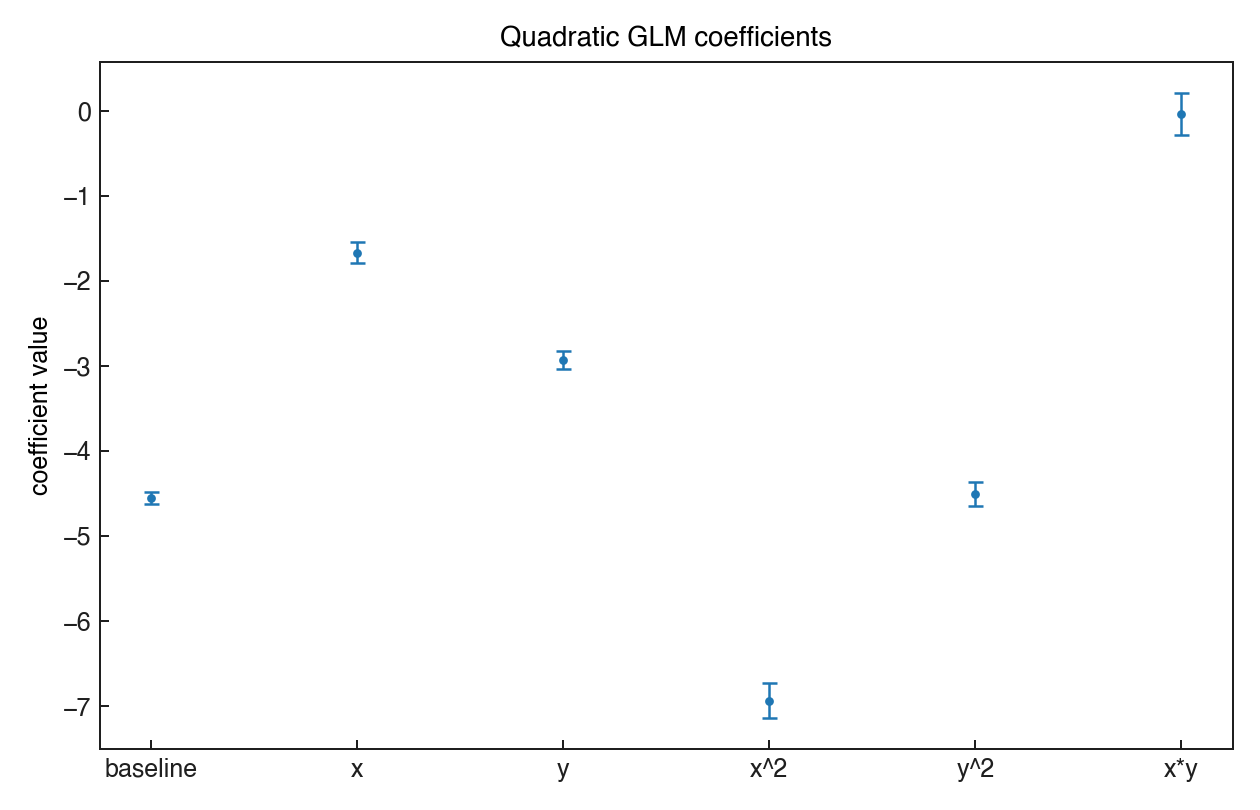

In [ ]:
# SECTION 3:
# visualize the raw data
fig = _prepare_figure("figure; plot(xN,yN,x_at_spiketimes,y_at_spiketimes,'r.')", figsize=(6.5, 6.0))
ax = fig.subplots(1, 1)
ax.plot(xN, yN, color="tab:blue", linewidth=0.5)
ax.plot(x_at_spiketimes, y_at_spiketimes, "r.", markersize=3.0)
matlab_trajectory_axes(ax, xlabel="x position (m)", ylabel="y position (m)")
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
ax.set_title("Rat trajectory with spike locations")

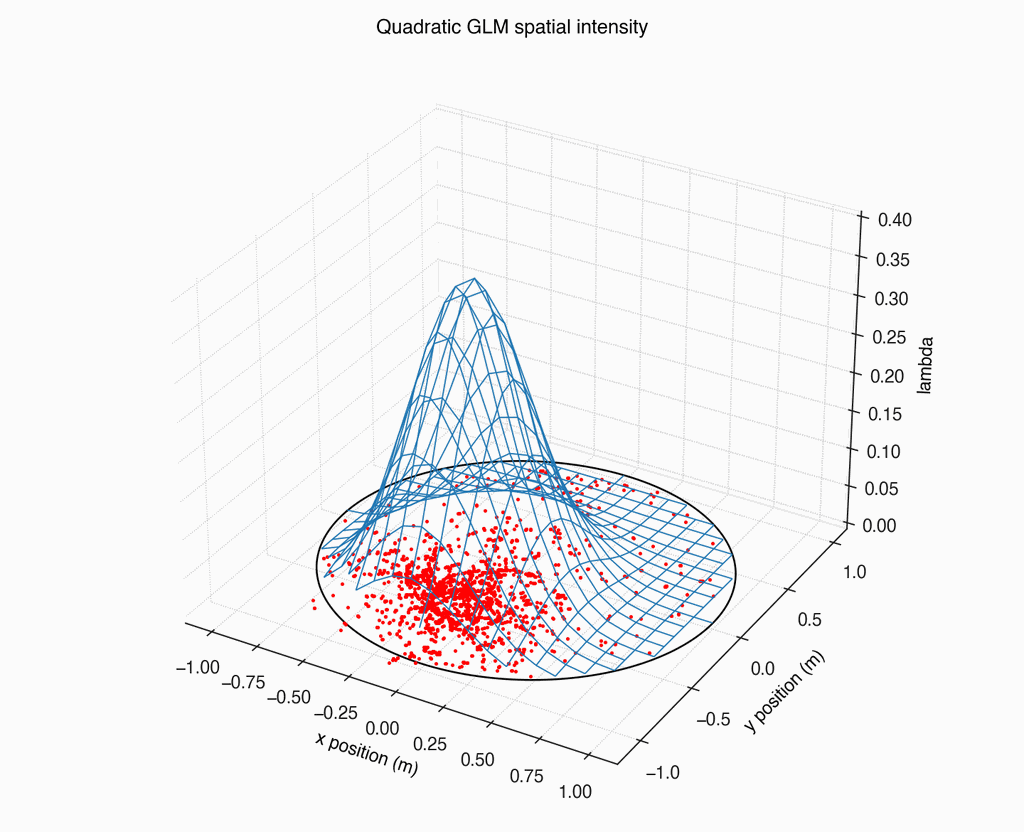

In [ ]:
# SECTION 4:
# fit a GLM model to the x and y positions
# [b,dev,stats] = glmfit([xN yN (xN.^2-mean(xN.^2)) (yN.^2-mean(yN.^2)) (xN.*yN-mean(xN.*yN))],spikes_binned,'poisson');
mean_xN_sq = np.mean(xN**2)
mean_yN_sq = np.mean(yN**2)
mean_xy = np.mean(xN * yN)
x_quadratic_centered = np.column_stack(
    [
        xN,
        yN,
        xN**2 - mean_xN_sq,
        yN**2 - mean_yN_sq,
        xN * yN - mean_xy,
    ]
)
centered_fit = fit_poisson_glm(x_quadratic_centered, spikes_binned)
fig = _prepare_figure("figure; errorbar(1:length(b), b, stats.se,'.')", figsize=(7.0, 4.5))
ax = fig.subplots(1, 1)
centered_beta = np.concatenate([[centered_fit.intercept], np.asarray(centered_fit.coefficients, dtype=float)])
centered_se = _poisson_standard_errors(x_quadratic_centered, centered_fit)
xpos = np.arange(centered_beta.size)
ax.errorbar(xpos, centered_beta, yerr=centered_se, fmt=".", color="tab:blue", capsize=3)
ax.set_xticks(xpos, ["baseline", "x", "y", "x^2", "y^2", "x*y"])
ax.set_ylabel("coefficient value")
ax.set_title("Quadratic GLM coefficients")


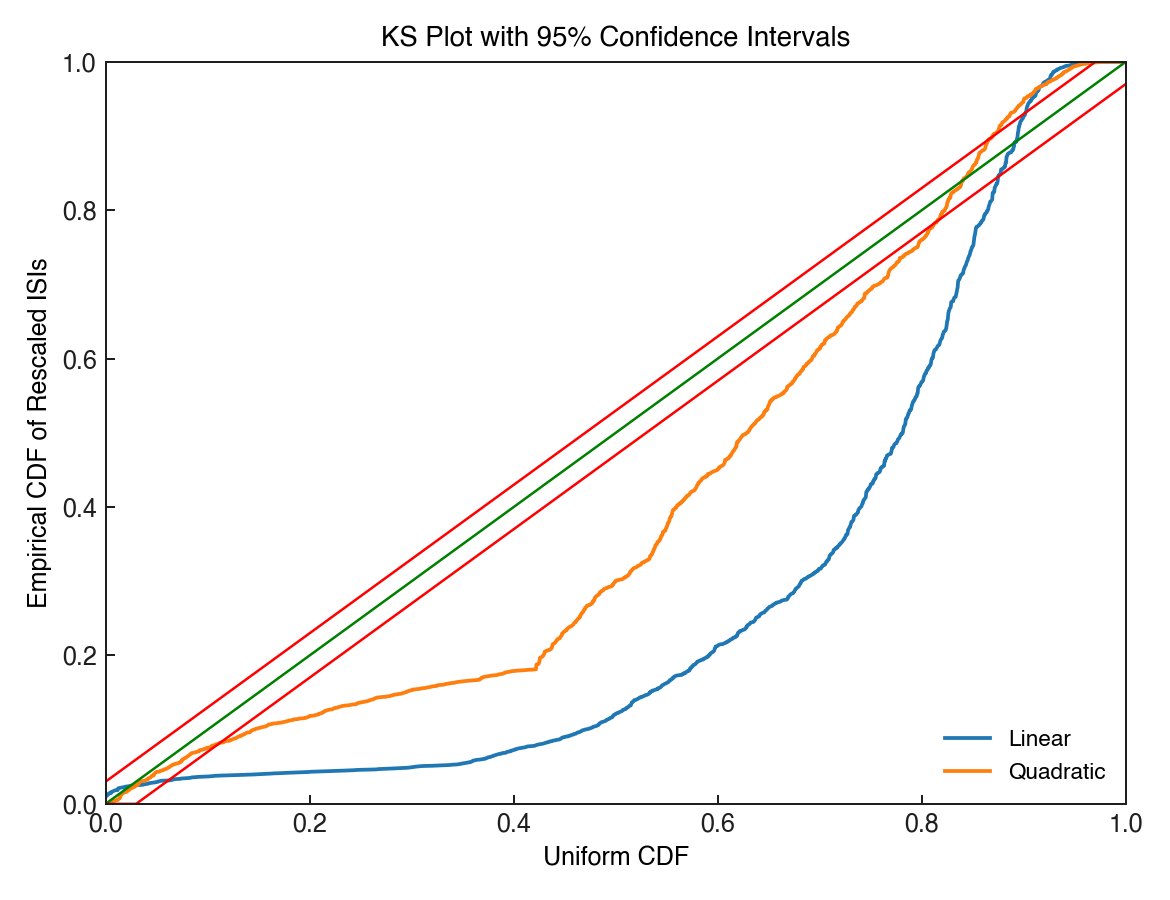

In [ ]:
# SECTION 5:
# visualize your model
# construct a grid of positions to plot the model against...
x_quadratic = np.column_stack([xN, yN, xN**2, yN**2, xN * yN])
quadratic_fit = fit_poisson_glm(x_quadratic, spikes_binned)
fig = _prepare_figure("figure; mesh(x_new,y_new,lambda,'AlphaData',0)", figsize=(8.0, 6.5))
ax = fig.add_subplot(111, projection="3d")
grid = np.arange(-1.0, 1.01, 0.1)
x_new, y_new = np.meshgrid(grid, grid)
y_new = np.flipud(y_new)
x_new = np.fliplr(x_new)
# compute lambda for each point on this grid using the GLM model
b = np.concatenate([[quadratic_fit.intercept], np.asarray(quadratic_fit.coefficients, dtype=float)])
lam_grid = np.exp(b[0] + b[1] * x_new + b[2] * y_new + b[3] * x_new**2 + b[4] * y_new**2 + b[5] * x_new * y_new)
lam_grid = np.where((x_new**2 + y_new**2) <= 1.0, lam_grid, np.nan)
# plot lambda as a function of position over this grid (Python uses
# ``plot_wireframe`` as the analogue of MATLAB ``mesh``).
ax.plot_wireframe(x_new, y_new, lam_grid, rstride=1, cstride=1, color="tab:blue", linewidth=0.7)
theta = np.linspace(-np.pi, np.pi, 400)
# MATLAB plot3(cos(...),sin(...),0)
ring_x = np.cos(theta)
ring_y = np.sin(theta)
ring_z = np.zeros_like(theta)
ax.plot(ring_x, ring_y, ring_z, color="k", linewidth=1.0)
ax.plot(x_at_spiketimes, y_at_spiketimes, np.zeros_like(x_at_spiketimes), "r.", markersize=2.0)
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
ax.set_zlabel("lambda")
ax.set_title("Quadratic GLM spatial intensity")


In [ ]:
# SECTION 6:
# Compare a linear model versus a Gaussian GLM model.
# [b_lin,dev_lin,stats_lin] = glmfit([xN yN],spikes_binned,'poisson');
# [b_quad,dev_quad,stats_quad] = glmfit([xN yN xN.^2 yN.^2 xN.*yN],spikes_binned,'poisson');
x_linear = np.column_stack([xN, yN])
linear_fit = fit_poisson_glm(x_linear, spikes_binned)
# centered_fit / quadratic_fit were fit above; the centered features are
# numerically equivalent to the raw quadratic features for the KS comparison.
b_lin = np.concatenate([[linear_fit.intercept], np.asarray(linear_fit.coefficients, dtype=float)])
b_quad = np.concatenate([[quadratic_fit.intercept], np.asarray(quadratic_fit.coefficients, dtype=float)])
# lambdaEst_lin  = exp( b_lin(1) + b_lin(2)*xN+b_lin(3)*yN);
# lambdaEst_quad = exp( b_quad(1) + b_quad(2)*xN+b_quad(3)*yN+b_quad(4)*xN.^2 +b_quad(5)*yN.^2 +b_quad(6)*xN.*yN);
lambdaEst_lin = np.exp(b_lin[0] + b_lin[1] * xN + b_lin[2] * yN)
lambdaEst_quad = np.exp(b_quad[0] + b_quad[1] * xN + b_quad[2] * yN + b_quad[3] * xN**2 + b_quad[4] * yN**2 + b_quad[5] * xN * yN)
lambda_linear_hz = lambdaEst_lin * sample_rate
lambda_quadratic_hz = lambdaEst_quad * sample_rate
lambda_linear = Covariate(T, lambda_linear_hz, "lambda_linear", "time", "s", "Hz", ["Linear"])
lambda_quadratic = Covariate(T, lambda_quadratic_hz, "lambda_quadratic", "time", "s", "Hz", ["Quadratic"])
print(
    {
        "linear_mean_rate_hz": round(float(np.mean(lambda_linear_hz)), 4),
        "quadratic_mean_rate_hz": round(float(np.mean(lambda_quadratic_hz)), 4),
    }
)


In [ ]:
# SECTION 7:
# Make the KS Plot
# *******  K-S Plot  *******************
# graph the K-S plot and confidence intervals for the K-S statistic
_, _, x_linear_ks, ks_linear, _ = Analysis.computeKSStats(nst, lambda_linear)
_, _, x_quadratic_ks, ks_quadratic, _ = Analysis.computeKSStats(nst, lambda_quadratic)
x_axis = np.asarray(x_linear_ks, dtype=float).reshape(-1)
ks_linear_arr = np.asarray(ks_linear, dtype=float).reshape(-1)
ks_quadratic_arr = np.asarray(ks_quadratic, dtype=float).reshape(-1)
# KSSorted = sort(KS);
ks_sorted_linear = np.sort(ks_linear_arr)
ks_sorted_quadratic = np.sort(ks_quadratic_arr)
fig = _prepare_figure("figure; plot(([1:N]-.5)/N, KSSorted, ...)", figsize=(6.5, 5.0))
ax = fig.subplots(1, 1)
# MATLAB plot(([1:N]-.5)/N, KSSorted, 0:.01:1,0:.01:1, 'g', 0:.01:1, [0:.01:1]+1.36/sqrt(N), 'r', 0:.01:1,[0:.01:1]-1.36/sqrt(N), 'r')
ax.plot(x_axis, ks_sorted_linear, color="tab:blue", linewidth=1.5, label="Linear")
ax.plot(x_axis, ks_sorted_quadratic, color="tab:orange", linewidth=1.5, label="Quadratic")
ax.plot([0.0, 1.0], [0.0, 1.0], "g", linewidth=1.0)
# 1.36/sqrt(N) confidence interval bands (red, 95% CI) — two sqrt(N) factors
# match MATLAB's two sqrt() calls embedded in the same plot() invocation.
ci_upper = np.sqrt(x_axis.size)
ci_lower = np.sqrt(x_axis.size)
ax.plot(x_axis, np.clip(x_axis + 1.36 / ci_upper, 0.0, 1.0), "r", linewidth=1.0)
ax.plot(x_axis, np.clip(x_axis - 1.36 / ci_lower, 0.0, 1.0), "r", linewidth=1.0)
plt.axis([0.0, 1.0, 0.0, 1.0])
plt.xlabel("Uniform CDF")
plt.ylabel("Empirical CDF of Rescaled ISIs")
plt.title("KS Plot with 95% Confidence Intervals")
plt.legend(["Linear", "Quadratic"], loc="lower right", frameon=False)
__tracker.finalize()
